Setup + the 6 most important Seaborn charts

C:\Users\pk362\AppData\Local\Temp\ipykernel_17948\3989869509.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Fare', data=df, ax=axes[0,1], palette='Set2')
C:\Users\pk362\AppData\Local\Temp\ipykernel_17948\3989869509.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1,2], palette='Blues_d')


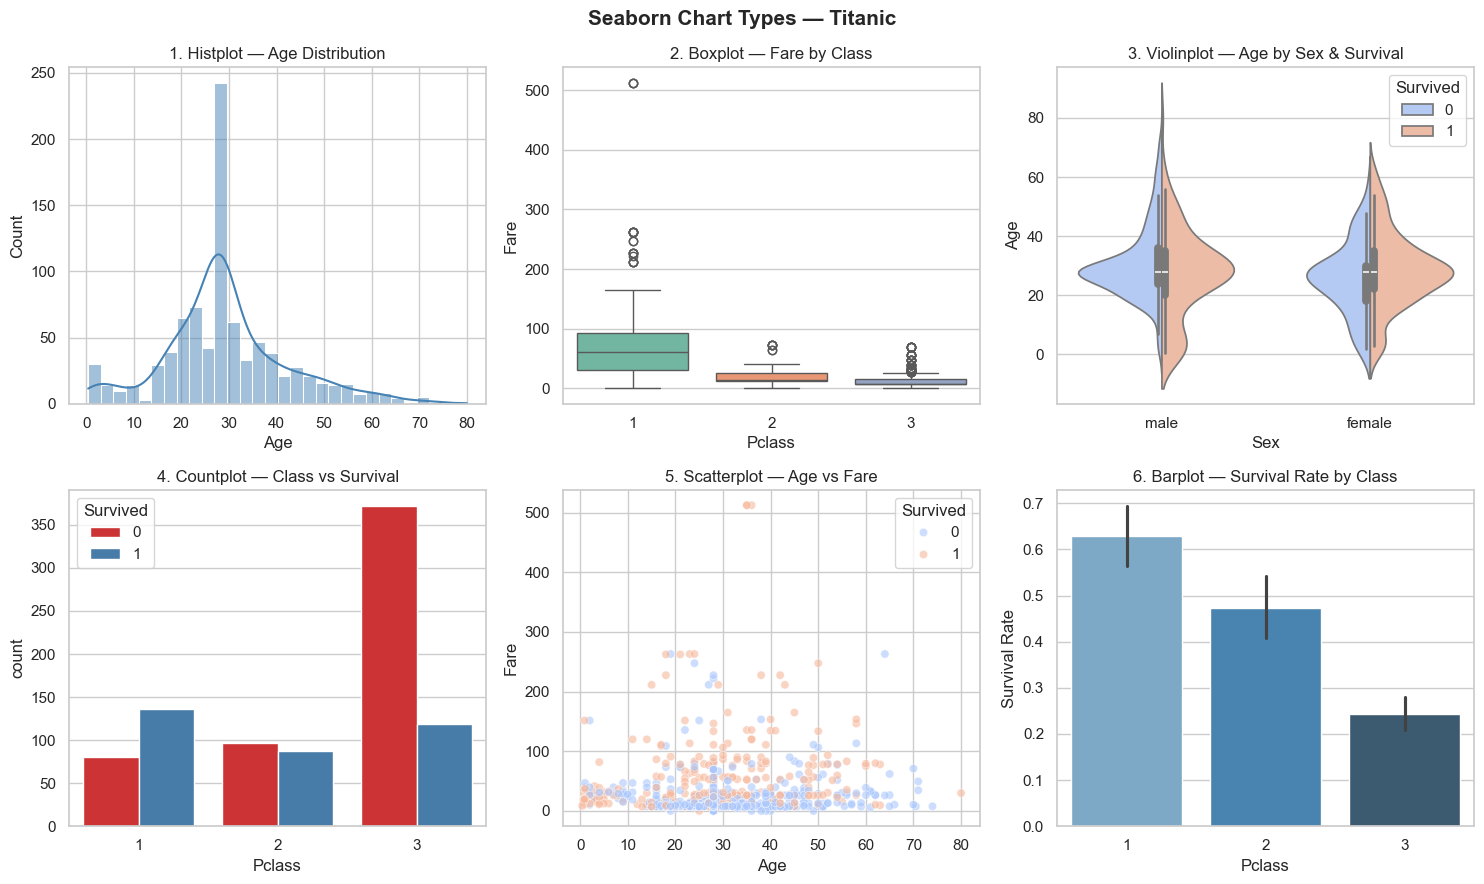

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load Titanic
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])

sns.set_theme(style='whitegrid')  # clean background

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Seaborn Chart Types — Titanic', fontsize=15, fontweight='bold')

# 1. Histogram + KDE — distribution shape
sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('1. Histplot — Age Distribution')

# 2. Boxplot — spread + outliers per group
sns.boxplot(x='Pclass', y='Fare', data=df, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('2. Boxplot — Fare by Class')

# 3. Violin plot — boxplot + distribution shape
sns.violinplot(x='Sex', y='Age', hue='Survived', data=df,
               ax=axes[0,2], palette='coolwarm', split=True)
axes[0,2].set_title('3. Violinplot — Age by Sex & Survival')

# 4. Count plot — categorical counts
sns.countplot(x='Pclass', hue='Survived', data=df, ax=axes[1,0], palette='Set1')
axes[1,0].set_title('4. Countplot — Class vs Survival')

# 5. Scatter with hue — two variables + category colour
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df,
                ax=axes[1,1], alpha=0.6, palette='coolwarm')
axes[1,1].set_title('5. Scatterplot — Age vs Fare')

# 6. Bar plot — mean with confidence interval
sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1,2], palette='Blues_d')
axes[1,2].set_title('6. Barplot — Survival Rate by Class')
axes[1,2].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()



Correlation heatmap — find which features relate to surviva

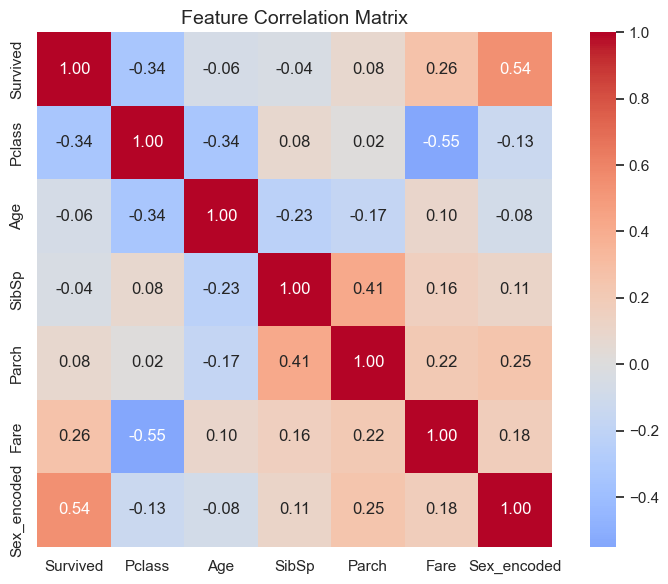


Correlation with Survived (sorted):
Survived       1.000000
Sex_encoded    0.543351
Fare           0.257307
Parch          0.081629
SibSp         -0.035322
Age           -0.064910
Pclass        -0.338481
Name: Survived, dtype: float64


In [ ]:

df['Sex_encoded'] = (df['Sex'] == 'female').astype(int)
df['Embarked_C'] = (df['Embarked'] == 'C').astype(int)

# Select numeric columns
numeric_cols = ['Survived','Pclass','Age','SibSp','Parch','Fare','Sex_encoded']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr,
            annot=True,        # show numbers in cells
            fmt='.2f',         # 2 decimal places
            cmap='coolwarm',   # red = positive, blue = negative
            center=0,
            square=True,
            ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Print top features correlated with Survived
print('\nCorrelation with Survived (sorted):')
print(corr['Survived'].sort_values(ascending=False))


Pairplot = scatter matrix — every feature vs every other feature
Coloured by Survived so patterns jump out

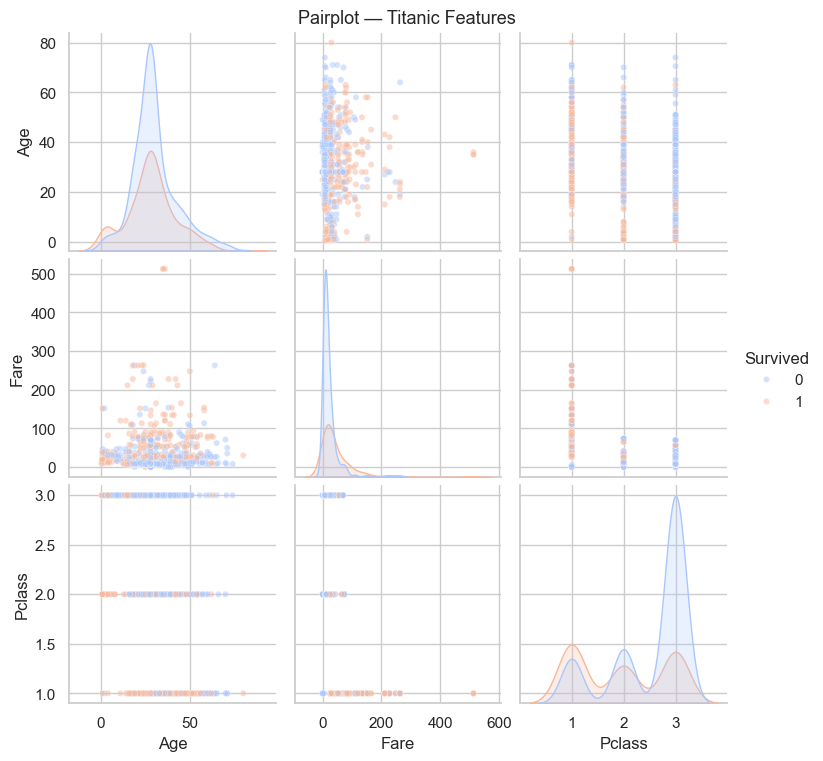

Tip: diagonal = distribution of each feature
Off-diagonal = scatter of two features, coloured by survival


In [ ]:

cols = ['Survived','Age','Fare','Pclass']
sns.pairplot(
    df[cols].dropna(),
    hue='Survived',
    palette='coolwarm',
    plot_kws={'alpha': 0.5, 's': 20},
    diag_kind='kde'
)
plt.suptitle('Pairplot — Titanic Features', y=1.01, fontsize=13)
plt.show()

print('Tip: diagonal = distribution of each feature')
print('Off-diagonal = scatter of two features, coloured by survival')
